In [2]:
import numpy as np
import pandas as pd
from pandas import read_excel

In [3]:
df=read_excel('/content/crop yield data sheet.xlsx')

In [5]:
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [6]:
df.head()

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0


In [12]:
x_train,x_test,y_train,y_test=train_test_split(df[['Temperatue','Rain Fall (mm)','Nitrogen (N)','Phosphorus (P)','Potassium (K)']],df['Yeild (Q/acre)'],test_size=0.2,random_state=42)

In [11]:
# Convert 'Temperatue' to numeric, coercing errors
df['Temperatue'] = pd.to_numeric(df['Temperatue'], errors='coerce')

# Drop rows with any NaN values that resulted from the coercion or were already present
df.dropna(inplace=True)

# Verify data types and check for NaNs
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      99 non-null     float64
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(7)
memory usage: 6.2 KB
None
Rain Fall (mm)    0
Fertilizer        0
Temperatue        0
Nitrogen (N)      0
Phosphorus (P)    0
Potassium (K)     0
Yeild (Q/acre)    0
dtype: int64


In [13]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(x_train, y_train)

print("Model training complete.")

Model training complete.


In [14]:
# Make predictions on the test data
y_pred = model.predict(x_test)

# Display the predictions
print("Predictions:")
display(y_pred)

Predictions:


array([11.09896506, 11.13531946,  7.26675582, 10.83729511,  7.8189137 ,
       10.70272348, 10.50905818, 11.41725201, 11.48216375, 11.1469316 ,
        6.48043042, 11.07536496,  8.21916175,  6.13128704, 10.94171375,
       10.81844264,  7.45993142, 10.81356841, 10.52443911,  8.41393248])

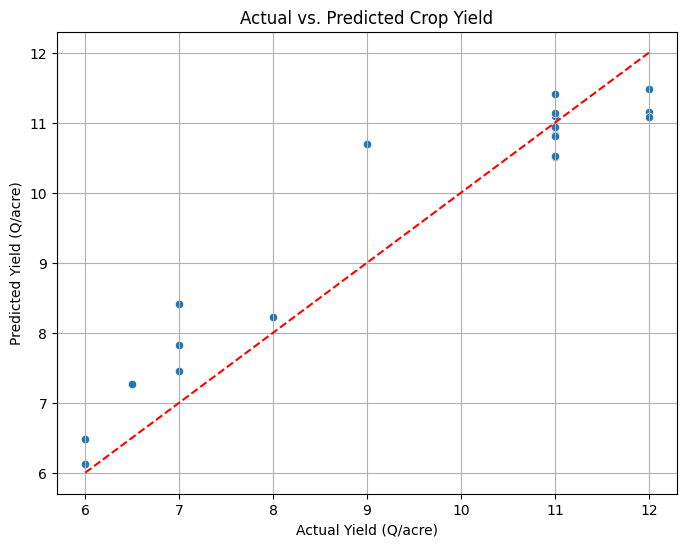

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Yield (Q/acre)")
plt.ylabel("Predicted Yield (Q/acre)")
plt.title("Actual vs. Predicted Crop Yield")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Ideal prediction line
plt.grid(True)
plt.show()

In [19]:
# Take manual inputs for prediction
try:
    temp = float(input("Enter Temperature: "))
    rainfall = float(input("Enter Rain Fall (mm): "))
    nitrogen = float(input("Enter Nitrogen (N): "))
    phosphorus = float(input("Enter Phosphorus (P): "))
    potassium = float(input("Enter Potassium (K): "))

    # Create a DataFrame from the manual inputs
    manual_input = pd.DataFrame([[temp, rainfall, nitrogen, phosphorus, potassium]],
                                columns=['Temperatue', 'Rain Fall (mm)', 'Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)'])

    # Make a prediction using the trained model
    manual_prediction = model.predict(manual_input)

    print(f"\nPredicted Yeild (Q/acre): {manual_prediction[0]:.2f}")

except ValueError:
    print("Invalid input. Please enter numeric values.")
except Exception as e:
    print(f"An error occurred: {e}")

Enter Temperature: 28
Enter Rain Fall (mm): 200
Enter Nitrogen (N): 35
Enter Phosphorus (P): 36
Enter Potassium (K): 23

Predicted Yeild (Q/acre): 10.30
